<a href="https://www.kaggle.com/code/chumakoleksandr/cw29-09?scriptVersionId=353952712" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from collections import Counter

import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
data_dir = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"

dataset = datasets.ImageFolder(data_dir)

print("Кількість зображень:", len(dataset))
print("Класи:", dataset.classes)

counts = Counter(dataset.targets)

for i, name in enumerate(dataset.classes):
    print(f"{name}: {counts[i]}")

Кількість зображень: 952
Класи: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
bengal: 177
domestic_shorthair: 170
maine_coon: 190
ragdoll: 207
siamese: 208


In [3]:
train_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [4]:
class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = self.transformer(img)
        return img, label

In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = TransformDataset(train_data, train_transformer)
test_dataset = TransformDataset(test_data, test_transformer)

print("Тренувальні зображення:", len(train_dataset))
print("Тестові зображення:", len(test_dataset))

Тренувальні зображення: 761
Тестові зображення: 191


In [6]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Розмір пакета зображень:", images.shape)
print("Розмір пакета міток:", labels.shape)

Розмір пакета зображень: torch.Size([32, 3, 224, 224])
Розмір пакета міток: torch.Size([32])


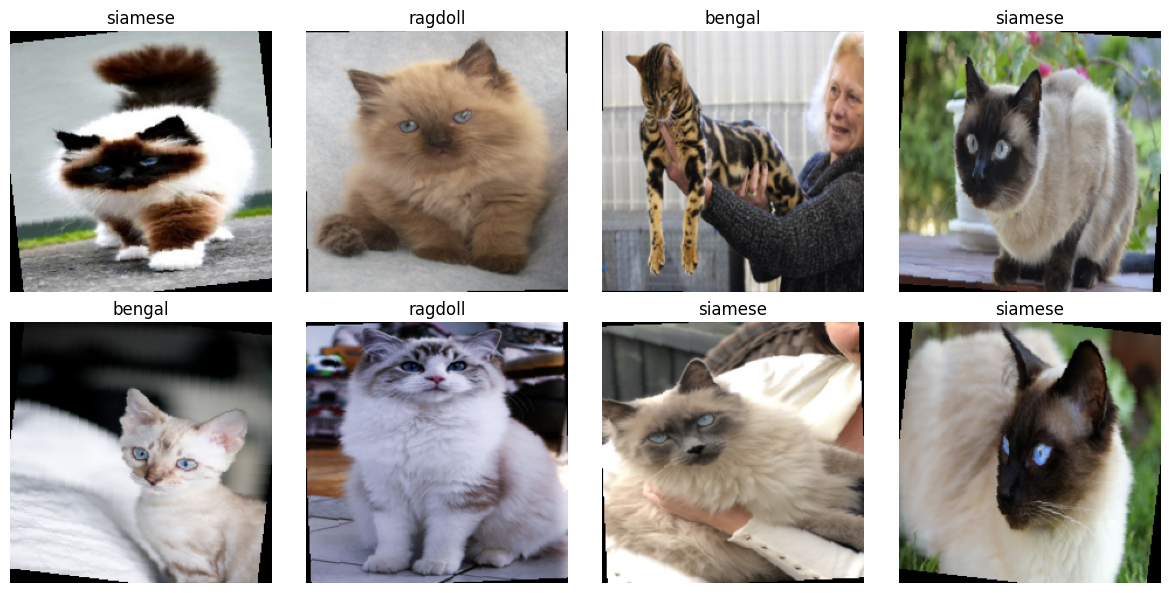

In [7]:
plt.figure(figsize=(12, 6))

for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(dataset.classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()